# 02 — PyTorch verstehen: Shapes, Batches, Optimierer, Devices

Notebook 01 hat gezeigt, *dass* ein MLP einen Peak lernen kann. Hier geht es eine Ebene tiefer: **wie PyTorch das organisiert** — wie Tensoren im Speicher liegen, was Broadcasting wirklich tut, wie aus Daten Mini-Batches werden, was ein Optimierer im Parameterraum macht, und wann die GPU (MPS) überhaupt hilft.

Leitprinzip: **so viel wie möglich sichtbar machen**. Fast jeder Abschnitt endet in einem Bild.

---

## Notation

Wir übernehmen ab hier konsequent die Notation aus *Mathematics for Machine Learning* (Deisenroth, Faisal, Ong — kurz **MML**, Table of Symbols, S. 6). Das lohnt sich: Wenn du im Buch liest und hier programmierst, meinen beide dasselbe.

| MML-Symbol | Bedeutung | in PyTorch |
|---|---|---|
| $a, b, \gamma$ | Skalare (klein, kursiv) | Python-`float` oder 0-dim Tensor |
| $\boldsymbol{x}, \boldsymbol{y}, \boldsymbol{\theta}$ | Vektoren (fett, klein) | 1-dim Tensor, `shape (D,)` |
| $\boldsymbol{A}, \boldsymbol{X}$ | Matrizen (fett, groß) | 2-dim Tensor, `shape (N, D)` |
| $\boldsymbol{x}^\top,\ \boldsymbol{A}^\top$ | Transponierte | `x.T`, `A.mT` |
| $N$, Index $n=1,\dots,N$ | Anzahl **Datenpunkte** | Zeilen-/Batch-Achse (Achse 0) |
| $D$, Index $d=1,\dots,D$ | Anzahl **Dimensionen** (Features) | Spalten-/Feature-Achse (Achse 1) |
| $\boldsymbol{\theta}$ | Parametervektor des Modells | `model.parameters()` |
| $\gamma$ | Schrittweite (*step-size*, = learning rate) | `lr=...` |
| $L(\boldsymbol{\theta})$, $L_n(\boldsymbol{\theta})$ | Gesamt-Loss / Loss von Datenpunkt $n$ | `loss`, Beitrag eines Samples |
| $\lVert\cdot\rVert$ | Norm (euklidisch, wenn nichts anderes gesagt) | `torch.linalg.norm` |

Ein Hinweis zur Konvention: MML schreibt Gradienten als **Zeilenvektoren** (Kap. 5.1, Randnotiz auf S. 228) und setzt in Gleichung (7.6) deshalb ein Transponat. PyTorch legt `p.grad` immer in derselben Form ab wie `p` selbst. Wir rechnen hier durchgängig mit Spaltenvektoren und lassen die Transponate weg — die Mathematik ist dieselbe.

## Was wo im Buch steht

| Abschnitt hier | MML-Kapitel |
|---|---|
| 1 Tensoren & Speicher | Kap. 2.2 (Matrizen) |
| 2 Broadcasting | Kap. 2.2, 3.1 (Normen) |
| 3 Design-Matrix $\boldsymbol{X}\in\mathbb{R}^{N\times D}$ | Kap. 8.1 (Data, Models, Learning), 9.1 |
| 4 Dataset & DataLoader | Kap. 7.1.3 (SGD), Gl. (7.13)–(7.15) |
| 5 Optimierer im Parameterraum | Kap. 7.1, Beispiel 7.1, Abb. 7.3, Kap. 4.5 (SVD/Kondition) |
| 6 Full-Batch vs. Mini-Batch | Kap. 7.1.3, S. 232 |
| 7 `nn.Module` von innen | Kap. 8.2 (ERM), 8.6 (Model Selection) |
| 9 Fallstricke | Kap. 5.6 (Backprop & Autodiff) |

## Inhalt

1. Tensor-Anatomie: shape, dtype, device — und der flache Speicher darunter
2. Broadcasting (und der stille Bug, der jedem einmal passiert)
3. Die Design-Matrix $\boldsymbol{X} \in \mathbb{R}^{N\times D}$
4. `Dataset` & `DataLoader` — Mini-Batches als Näherung von $\nabla L(\boldsymbol{\theta})$
5. Optimierer sichtbar gemacht — Beispiel 7.1 aus dem Buch nachgebaut
6. Full-Batch vs. Mini-Batch vs. SGD
7. `nn.Module` von innen: Parameter, `state_dict`, `train()`/`eval()`, Speichern
8. Devices: CPU vs. MPS (Apple Silicon) — und wann die GPU *nicht* hilft
9. Typische Fallstricke, die still schiefgehen
10. Interaktiv: Optimierer-Spielplatz
11. Zusammenfassung, Videos & Standardliteratur

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

torch.manual_seed(0)
plt.rcParams["figure.dpi"] = 110

print("PyTorch:", torch.__version__)
print("MPS (Apple GPU) verfuegbar:", torch.backends.mps.is_available())


# --- kleine Plot-Helfer, die wir im ganzen Notebook wiederverwenden ---

def show_matrix(ax, M, title="", cmap="viridis", values=True, vmin=None, vmax=None,
                fs=8, aspect="equal"):
    '''Zeichnet einen 1D/2D-Tensor als Gitter mit Zahlen drin.'''
    M = M.detach().cpu().numpy() if torch.is_tensor(M) else np.asarray(M)
    M2 = M.reshape(1, -1) if M.ndim == 1 else M
    ax.imshow(M2, cmap=cmap, vmin=vmin, vmax=vmax, aspect=aspect)
    if values:
        for i in range(M2.shape[0]):
            for j in range(M2.shape[1]):
                ax.text(j, i, f"{M2[i, j]:.3g}", ha="center", va="center",
                        color="white", fontsize=fs)
    ax.set_title(f"{title}\nshape={tuple(M.shape)}", fontsize=9)
    ax.set_xticks(range(M2.shape[1]))
    ax.set_yticks(range(M2.shape[0]))
    ax.tick_params(labelsize=7)
    return ax


def contour_2d(ax, f, xlim=(-4, 4), ylim=(-2, 2), levels=25, n=200):
    '''Höhenlinien einer Funktion f: R^2 -> R (erwartet Tensor der shape (M,2)).'''
    xs = torch.linspace(*xlim, n)
    ys = torch.linspace(*ylim, n)
    XX, YY = torch.meshgrid(xs, ys, indexing="xy")
    pts = torch.stack([XX.reshape(-1), YY.reshape(-1)], dim=1)
    ZZ = f(pts).reshape(n, n)
    cs = ax.contour(XX, YY, ZZ, levels=levels, cmap="viridis", linewidths=0.7)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    return cs

PyTorch: 2.13.0
MPS (Apple GPU) verfuegbar: True


---
## 1. Tensor-Anatomie: shape, dtype, device — und der flache Speicher darunter

In Notebook 01 (Abschnitt 7b) hast du geklärt, was `shape` bedeutet und dass Daten- und Parameter-Tensoren zwei verschiedene Sorten sind. Hier kommt die Ebene darunter dazu, weil sie später drei Klassen von Bugs erklärt (Broadcasting, `view`-Fehler, langsamer Code):

**Ein Tensor ist ein *flacher* Speicherblock plus Metadaten, die sagen, wie er zu lesen ist.**

| Metadatum | Bedeutung |
|---|---|
| `shape` | Länge jeder Achse |
| `stride` | Wie viele Speicherplätze man überspringt, um in einer Achse einen Schritt zu gehen |
| `dtype` | Zahlentyp (`float32` ist der ML-Standard, `float64` für numerische Referenzrechnungen) |
| `device` | Wo die Zahlen physisch liegen (`cpu`, `mps`, `cuda`) |

Ein $3\times 4$-Tensor liegt also **nicht** als Rechteck im Speicher, sondern als 12 Zahlen hintereinander (*row-major*): erst Zeile 0, dann Zeile 1, dann Zeile 2. Der `stride` `(4, 1)` sagt: "eine Zeile weiter = 4 Plätze überspringen, eine Spalte weiter = 1 Platz".

A =
 tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

shape : (3, 4)
stride: (4, 1)  <- (Zeilenschritt, Spaltenschritt) im flachen Speicher
dtype : torch.float32
device: cpu
flach im Speicher: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0]


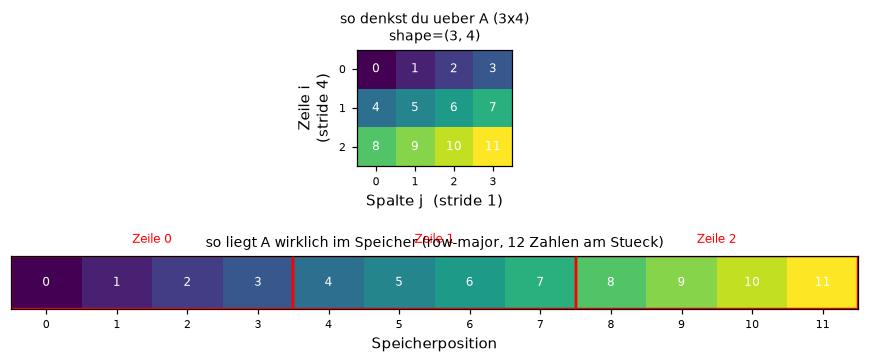

In [2]:
A = torch.arange(12, dtype=torch.float32).reshape(3, 4)

print("A =\n", A)
print("\nshape :", tuple(A.shape))
print("stride:", A.stride(), " <- (Zeilenschritt, Spaltenschritt) im flachen Speicher")
print("dtype :", A.dtype)
print("device:", A.device)
print("flach im Speicher:", A.flatten().tolist())

fig, axes = plt.subplots(2, 1, figsize=(8, 3.4),
                         gridspec_kw={"height_ratios": [2.2, 1]})

show_matrix(axes[0], A, "so denkst du ueber A (3x4)")
axes[0].set_xlabel("Spalte j  (stride 1)")
axes[0].set_ylabel("Zeile i\n(stride 4)")

# derselbe Tensor als flacher Speicherstreifen
flat = A.flatten()
axes[1].imshow(flat.reshape(1, -1), cmap="viridis", aspect="auto")
for k in range(12):
    axes[1].text(k, 0, f"{flat[k]:.0f}", ha="center", va="center", color="white", fontsize=8)
for k in (0, 4, 8):
    axes[1].add_patch(Rectangle((k - 0.5, -0.5), 4, 1, fill=False, ec="red", lw=1.6))
    axes[1].text(k + 1.5, -0.75, f"Zeile {k // 4}", ha="center", color="red", fontsize=8)
axes[1].set_title("so liegt A wirklich im Speicher (row-major, 12 Zahlen am Stueck)", fontsize=9)
axes[1].set_yticks([])
axes[1].set_xticks(range(12))
axes[1].tick_params(labelsize=7)
axes[1].set_xlabel("Speicherposition")
plt.tight_layout()
plt.show()

### `view` / `reshape` / `permute` / `T` — was davon kopiert Daten?

Weil der Speicher flach ist, sind viele "Umformungen" gar keine: Sie ändern **nur die Metadaten** und teilen sich denselben Speicher (*view*). Das ist schnell — aber es heißt auch, dass eine Änderung am einen Tensor im anderen sichtbar wird.

- `view` / `reshape`: gleiche Zahlen, gleiche Reihenfolge, neue Achsen-Aufteilung
- `permute` / `.T`: Achsen tauschen — Reihenfolge im Speicher bleibt, nur die `stride`s tauschen. Ergebnis ist **nicht mehr contiguous**.
- `.contiguous()`: erzwingt eine echte Kopie in Speicher-Reihenfolge (nötig, wenn danach `view` kommt).

Die Farbe im Bild ist der *Zahlenwert* — so siehst du sofort, welche Zahl wohin gewandert ist.

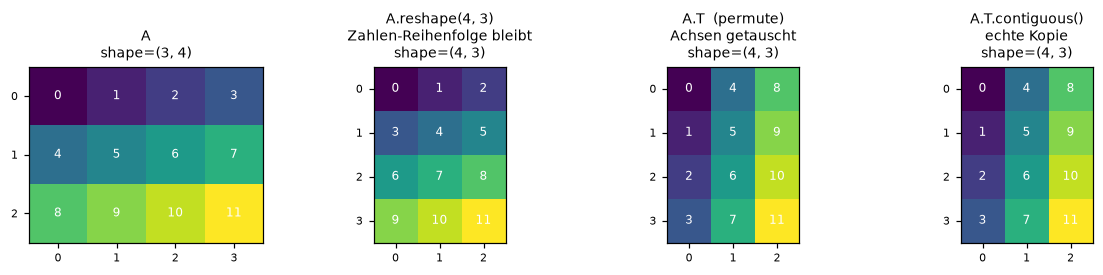

A.reshape(4,3) teilt Speicher mit A?  True
A.T           teilt Speicher mit A?  True
A.T.contiguous() teilt Speicher?     False

stride(A)   = (4, 1)
stride(A.T) = (1, 4)  <- nur vertauscht, kein Byte wurde bewegt
A.T ist contiguous: False

nach B[0,0] = 999  ->  A[0,0] = 999.0  (derselbe Speicher!)


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(11, 2.6))

show_matrix(axes[0], A, "A")
show_matrix(axes[1], A.reshape(4, 3), "A.reshape(4, 3)\nZahlen-Reihenfolge bleibt")
show_matrix(axes[2], A.T, "A.T  (permute)\nAchsen getauscht")
show_matrix(axes[3], A.T.contiguous(), "A.T.contiguous()\nechte Kopie")
plt.tight_layout()
plt.show()

print("A.reshape(4,3) teilt Speicher mit A? ", A.reshape(4, 3).data_ptr() == A.data_ptr())
print("A.T           teilt Speicher mit A? ", A.T.data_ptr() == A.data_ptr())
print("A.T.contiguous() teilt Speicher?    ", A.T.contiguous().data_ptr() == A.data_ptr())
print()
print("stride(A)   =", A.stride())
print("stride(A.T) =", A.T.stride(), " <- nur vertauscht, kein Byte wurde bewegt")
print("A.T ist contiguous:", A.T.is_contiguous())

# Konsequenz: ein view teilt den Speicher -> Aenderung wirkt auf beide
B = A.view(3, 4)
B[0, 0] = 999
print("\nnach B[0,0] = 999  ->  A[0,0] =", A[0, 0].item(), " (derselbe Speicher!)")
A[0, 0] = 0.0

---
## 2. Broadcasting — und der stille Bug, der jedem einmal passiert

Broadcasting ist die Regel, mit der PyTorch Tensoren **unterschiedlicher** Shape verrechnet. Der Algorithmus, von rechts nach links:

1. Shapes rechtsbündig ausrichten, fehlende Achsen links mit `1` auffüllen.
2. Pro Achse: Längen sind gleich → ok. Eine Länge ist `1` → wird auf die andere **gestreckt** (ohne zu kopieren). Sonst → Fehler.

Das ist enorm praktisch: ein $(N,1)$-Spaltenvektor und ein $(1,D)$-Zeilenvektor ergeben zusammen eine ganze $(N,D)$-Matrix — genau so bauen wir gleich Gitter und Design-Matrizen.

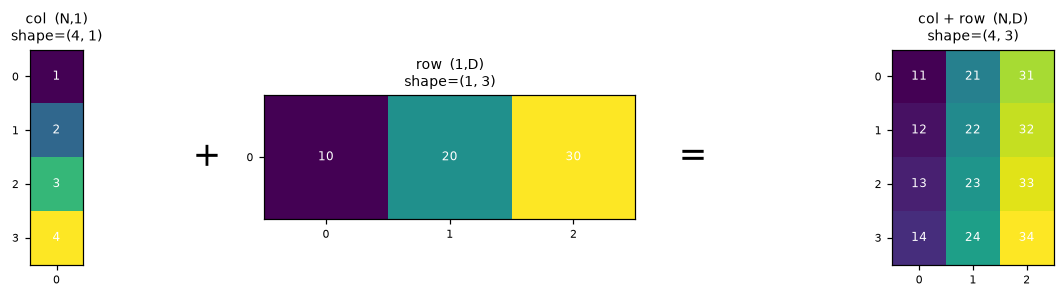

(4,1) + (1,3) -> (4, 3)


torch.broadcast_shapes((4,1), (1,3)) = (4, 3)


In [4]:
col = torch.tensor([[1.0], [2.0], [3.0], [4.0]])   # (N, 1)  = (4, 1)
row = torch.tensor([[10.0, 20.0, 30.0]])           # (1, D)  = (1, 3)
out = col + row                                    # -> (4, 3)

fig, axes = plt.subplots(1, 5, figsize=(11.5, 2.8),
                         gridspec_kw={"width_ratios": [1, 0.25, 2, 0.25, 2.4]})

show_matrix(axes[0], col, "col  (N,1)")
axes[1].text(0.5, 0.5, "+", ha="center", va="center", fontsize=22); axes[1].axis("off")
show_matrix(axes[2], row, "row  (1,D)")
axes[3].text(0.5, 0.5, "=", ha="center", va="center", fontsize=22); axes[3].axis("off")
show_matrix(axes[4], out, "col + row  (N,D)")
plt.tight_layout()
plt.show()

print("(4,1) + (1,3) ->", tuple(out.shape))
print("torch.broadcast_shapes((4,1), (1,3)) =", tuple(torch.broadcast_shapes((4, 1), (1, 3))))

### Der stille Bug: $(N,)$ gegen $(N,1)$

Genau dieselbe Regel schlägt zurück, wenn zwei Tensoren *fast* gleich aussehen. `y_pred` mit shape `(N, 1)` und `y_true` mit shape `(N,)` ergeben beim Subtrahieren **keine** $(N,)$-Residuen, sondern eine $(N,N)$-Matrix aller Differenzen $\hat y_i - y_j$. Der MSE läuft dann anstandslos durch — und ist trotzdem falsch.

Das ist tückisch, weil **keine Fehlermeldung** kommt: Der Loss ist plausibel klein, das Training "funktioniert", und das Modell lernt Unsinn. Schau dir das Bild an — links das, was du meinst, rechts das, was PyTorch rechnet.

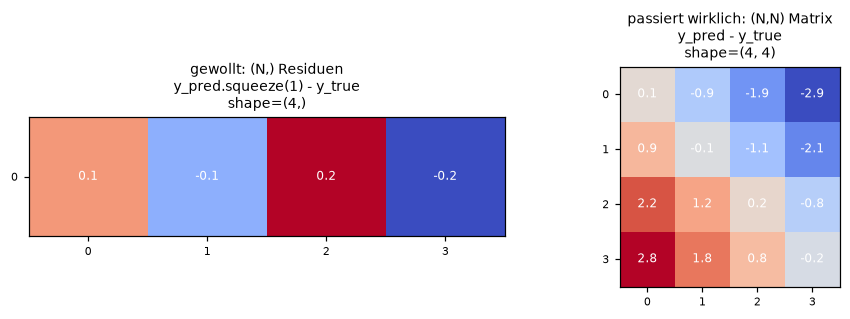

MSE mit (N,)  Residuen : 0.0250   <- korrekt
MSE mit (N,N) Matrix   : 2.3750   <- laeuft durch, ist aber Unsinn

Faustregel: nach jedem Schritt, der Shapes veraendern koennte, einmal .shape ausgeben.
Absicherung im Code:
  assert y_pred.shape == y_true.shape  ->  haette den Bug sofort gefunden


In [5]:
y_true_flat = torch.tensor([1.0, 2.0, 3.0, 4.0])      # (N,)   <- typisch aus NumPy/CSV
y_pred_col  = torch.tensor([[1.1], [1.9], [3.2], [3.8]])  # (N,1) <- typisch aus nn.Linear

richtig = y_pred_col.squeeze(1) - y_true_flat          # (N,)  gewollt
falsch  = y_pred_col - y_true_flat                     # (N,N) Broadcasting!

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
show_matrix(axes[0], richtig, "gewollt: (N,) Residuen\ny_pred.squeeze(1) - y_true", cmap="coolwarm")
show_matrix(axes[1], falsch, "passiert wirklich: (N,N) Matrix\ny_pred - y_true", cmap="coolwarm")
plt.tight_layout()
plt.show()

print(f"MSE mit (N,)  Residuen : {(richtig ** 2).mean():.4f}   <- korrekt")
print(f"MSE mit (N,N) Matrix   : {(falsch ** 2).mean():.4f}   <- laeuft durch, ist aber Unsinn")
print()
print("Faustregel: nach jedem Schritt, der Shapes veraendern koennte, einmal .shape ausgeben.")
print("Absicherung im Code:")
assert richtig.shape == y_true_flat.shape, "Shape-Mismatch!"
print("  assert y_pred.shape == y_true.shape  ->  haette den Bug sofort gefunden")

---
## 3. Die Design-Matrix $\boldsymbol{X} \in \mathbb{R}^{N \times D}$

MML führt in Kap. 8.1 die Konvention ein, die praktisch überall in ML gilt (und die PyTorch erwartet):

$$\boldsymbol{X} = \begin{bmatrix} \boldsymbol{x}_1^\top \\ \vdots \\ \boldsymbol{x}_N^\top \end{bmatrix} \in \mathbb{R}^{N \times D}, \qquad \boldsymbol{y} \in \mathbb{R}^{N}$$

- **Eine Zeile = ein Datenpunkt** $\boldsymbol{x}_n$ (bei uns: eine Messung)
- **Eine Spalte = ein Feature** $d$ (bei uns: ein Sensorkanal)

Deshalb steht $N$ immer **vorne**: `nn.Linear` und jeder DataLoader gehen davon aus, dass Achse 0 die Datenpunkte zählt. Das `unsqueeze(1)` aus Notebook 01 hat genau diese Konvention hergestellt ($D=1$, ein Feature).

Für das spätere Projekt ist das direkt die richtige Denkweise: $N$ Messungen mit je $D$ Sensorkanälen. Beim Spektrometer aus dem Project Brief wäre $D \approx 20$ Photodioden-Kanäle — die Struktur ist heute schon dieselbe.

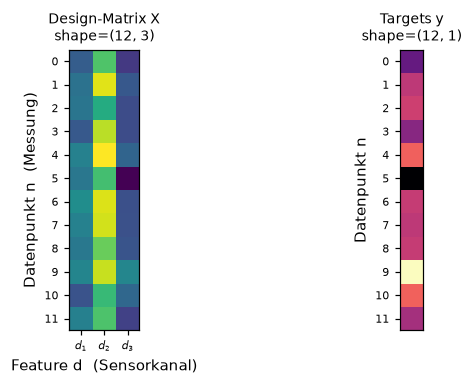

X: (12, 3)  = (N=12 Messungen, D=3 Kanaele)
y: (12,)  = ein Zielwert pro Messung

x_3 (dritte Messung, alle Kanaele): [0.8735948801040649, 1.65391206741333, 0.3289099931716919]
Kanal 1 ueber alle Messungen       : [0.550000011920929, 0.8299999833106995, 0.8700000047683716, 0.49000000953674316, 1.0499999523162842, 0.8999999761581421, 1.2300000190734863, 1.0399999618530273, 0.9100000262260437, 1.100000023841858, 0.4099999964237213, 1.0299999713897705]


In [6]:
# Spielzeug-"Messreihe": N Messungen, D Sensorkanaele
N, D = 12, 3
X = torch.randn(N, D) * 0.4 + torch.tensor([1.0, 2.5, 0.2])   # Broadcasting: (N,D) + (D,)
y = X @ torch.tensor([0.5, -0.3, 2.0]) + 0.05 * torch.randn(N)  # (N,)

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.6),
                         gridspec_kw={"width_ratios": [3, 1]})

show_matrix(axes[0], X, "Design-Matrix X", values=False)
axes[0].set_xlabel("Feature d  (Sensorkanal)")
axes[0].set_ylabel("Datenpunkt n  (Messung)")
axes[0].set_xticks(range(D), [f"$d_{i+1}$" for i in range(D)])

show_matrix(axes[1], y.unsqueeze(1), "Targets y", values=False, cmap="magma")
axes[1].set_xticks([])
axes[1].set_ylabel("Datenpunkt n")
plt.tight_layout()
plt.show()

print(f"X: {tuple(X.shape)}  = (N={N} Messungen, D={D} Kanaele)")
print(f"y: {tuple(y.shape)}  = ein Zielwert pro Messung")
print("\nx_3 (dritte Messung, alle Kanaele):", X[2].tolist())
print("Kanal 1 ueber alle Messungen       :", X[:, 0].round(decimals=2).tolist())

---
## 4. `Dataset` & `DataLoader` — Mini-Batches als Näherung des Gradienten

Jetzt der eigentliche Grund, warum es DataLoader überhaupt gibt. MML formuliert das in Kap. 7.1.3 sauber. Der Gesamt-Loss ist eine **Summe über Datenpunkte** (Gl. 7.13):

$$L(\boldsymbol{\theta}) = \sum_{n=1}^{N} L_n(\boldsymbol{\theta})$$

Ein voller Gradientenschritt (Gl. 7.15) braucht damit *alle* $N$ Einzelgradienten:

$$\boldsymbol{\theta}_{i+1} = \boldsymbol{\theta}_i - \gamma_i \sum_{n=1}^{N} \nabla L_n(\boldsymbol{\theta}_i)$$

Bei großem $N$ ist das teuer. Die zentrale Einsicht des Buchs (S. 232): Für Konvergenz braucht man **nicht den exakten Gradienten**, sondern nur einen *erwartungstreuen* (unbiased) Schätzer davon. Eine zufällige Teilmenge der $L_n$ liefert genau das:

- **großer** Mini-Batch → genauerer Gradient, ruhigere Konvergenz, teurer pro Schritt
- **kleiner** Mini-Batch → verrauschter Gradient, billiger, und das Rauschen hilft manchmal aus schlechten lokalen Minima heraus

Genau diese Teilmengen zieht der `DataLoader`. `Dataset` beantwortet dabei nur zwei Fragen — *"wie viele Datenpunkte hast du?"* (`__len__`) und *"gib mir Datenpunkt $n$"* (`__getitem__`) —, der `DataLoader` kümmert sich um Mischen, Bündeln und (optional) paralleles Laden.

In [7]:
from torch.utils.data import Dataset, DataLoader, TensorDataset

# --- Variante A: eigene Dataset-Klasse (volle Kontrolle) ---
class MeasurementDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y

    def __len__(self):                 # "wie viele Datenpunkte?"  -> N
        return self.X.shape[0]

    def __getitem__(self, n):          # "gib mir Datenpunkt n"    -> (x_n, y_n)
        return self.X[n], self.y[n]

ds = MeasurementDataset(X, y)

# --- Variante B: fuer Tensoren im Speicher reicht TensorDataset ---
ds_simple = TensorDataset(X, y)

print("len(ds) =", len(ds), " (= N)")
x_n, y_n = ds[2]
print("ds[2] ->", tuple(x_n.shape), tuple(y_n.shape), " <- EIN Datenpunkt, ohne Batch-Achse")

loader = DataLoader(ds, batch_size=4, shuffle=True)
xb, yb = next(iter(loader))
print("\nEin Batch aus dem DataLoader:")
print("  xb:", tuple(xb.shape), " <- (B, D): der DataLoader stapelt B Datenpunkte zur Batch-Achse")
print("  yb:", tuple(yb.shape))
print(f"\n{len(loader)} Batches pro Epoche (N={len(ds)}, batch_size=4)")

len(ds) = 12  (= N)
ds[2] -> (3,) ()  <- EIN Datenpunkt, ohne Batch-Achse

Ein Batch aus dem DataLoader:
  xb: (4, 3)  <- (B, D): der DataLoader stapelt B Datenpunkte zur Batch-Achse
  yb: (4,)

3 Batches pro Epoche (N=12, batch_size=4)


### Was `shuffle=True` konkret tut

Der DataLoader zerlegt die $N$ Indizes in Batches. Ohne Mischen bekommt jede Epoche exakt dieselben Gruppen — mit Mischen wird vor jeder Epoche neu gezogen. Im Bild: Zeile = Epoche, Spalte = Datenpunkt $n$, Farbe = in welchem Batch dieser Punkt in dieser Epoche gelandet ist.

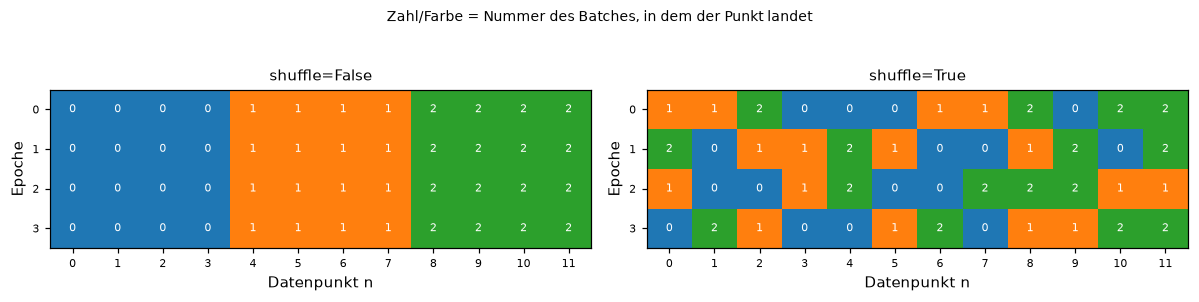

shuffle=False: jede Epoche identisch -> das Modell sieht immer dieselben Gruppen
shuffle=True : jede Epoche neu gemischt -> unabhaengigere Gradienten-Schaetzungen

Weitere nuetzliche Argumente:
  drop_last=True   letzten (kleineren) Batch verwerfen -> alle Batches gleich gross
  num_workers=k    k Prozesse laden parallel (lohnt bei Bildern/Dateien, nicht bei Tensoren im RAM)


In [8]:
def batch_map(shuffle, epochs=4, batch_size=4):
    '''Fuer jede Epoche: welcher Datenpunkt landet in welchem Batch?'''
    dl = DataLoader(TensorDataset(torch.arange(N), torch.arange(N)),
                    batch_size=batch_size, shuffle=shuffle)
    M = torch.zeros(epochs, N)
    for e in range(epochs):
        for b, (idx, _) in enumerate(dl):
            M[e, idx] = b
    return M

fig, axes = plt.subplots(1, 2, figsize=(11, 2.6))
for ax, sh in zip(axes, [False, True]):
    M = batch_map(shuffle=sh)
    ax.imshow(M, cmap="tab10", aspect="auto", vmin=0, vmax=9)
    for e in range(M.shape[0]):
        for n in range(N):
            ax.text(n, e, int(M[e, n].item()), ha="center", va="center", fontsize=7, color="white")
    ax.set_title(f"shuffle={sh}", fontsize=10)
    ax.set_xlabel("Datenpunkt n")
    ax.set_ylabel("Epoche")
    ax.set_xticks(range(N)); ax.set_yticks(range(M.shape[0]))
    ax.tick_params(labelsize=7)
plt.suptitle("Zahl/Farbe = Nummer des Batches, in dem der Punkt landet", fontsize=9, y=1.04)
plt.tight_layout()
plt.show()

print("shuffle=False: jede Epoche identisch -> das Modell sieht immer dieselben Gruppen")
print("shuffle=True : jede Epoche neu gemischt -> unabhaengigere Gradienten-Schaetzungen")
print("\nWeitere nuetzliche Argumente:")
print("  drop_last=True   letzten (kleineren) Batch verwerfen -> alle Batches gleich gross")
print("  num_workers=k    k Prozesse laden parallel (lohnt bei Bildern/Dateien, nicht bei Tensoren im RAM)")

---
## 5. Optimierer sichtbar gemacht — Beispiel 7.1 aus dem Buch nachgebaut

In Notebook 01 hast du Gradientenabstieg an *einem* Parameterpaar gesehen, aber nur als Loss-Kurve. Jetzt schauen wir uns den **Weg durch den Parameterraum** an — dafür nehmen wir exakt das Beispiel aus MML Kap. 7.1 (Beispiel 7.1, S. 228; die zugehörige Abbildung ist Abb. 7.3 auf S. 229):

$$f(\boldsymbol{x}) = \tfrac{1}{2}\boldsymbol{x}^\top \begin{bmatrix} 2 & 1 \\ 1 & 20\end{bmatrix}\boldsymbol{x} - \begin{bmatrix}5 \\ 3\end{bmatrix}^\top \boldsymbol{x}, \qquad \nabla f(\boldsymbol{x}) = \boldsymbol{A}\boldsymbol{x} - \boldsymbol{b}$$

Das Buch startet bei $\boldsymbol{x}_0 = [-3, -1]^\top$ mit Schrittweite $\gamma = 0.085$ und gibt die ersten Schritte explizit an: $\boldsymbol{x}_1 = [-1.98,\ 1.21]^\top$ und $\boldsymbol{x}_2 = [-1.32,\ -0.42]^\top$. Das ist ein guter Test — wenn unsere Implementierung dieselben Zahlen liefert, haben wir die Update-Regel (Gl. 7.6) richtig verstanden:

$$\boldsymbol{x}_{i+1} = \boldsymbol{x}_i - \gamma_i \nabla f(\boldsymbol{x}_i)$$

In [9]:
A_mml = torch.tensor([[2.0, 1.0], [1.0, 20.0]])
b_mml = torch.tensor([5.0, 3.0])

def f_mml(x):                       # x: (M, 2) -> (M,)
    return 0.5 * (x @ A_mml * x).sum(-1) - x @ b_mml

def grad_f_mml(x):                  # analytisch: A x - b
    return x @ A_mml.T - b_mml

def gd_path(x0, gamma, steps=30, momentum=0.0):
    '''Gradientenabstieg von Hand, optional mit Momentum (MML Gl. 7.11/7.12).'''
    x = x0.clone()
    dx = torch.zeros_like(x)        # Delta x_i, das "Gedaechtnis"
    path = [x.clone()]
    for _ in range(steps):
        dx = momentum * dx - gamma * grad_f_mml(x)
        x = x + dx
        path.append(x.clone())
    return torch.stack(path)

x0 = torch.tensor([-3.0, -1.0])
path_book = gd_path(x0, gamma=0.085, steps=30)

print("Vergleich mit den Zahlen aus MML Beispiel 7.1 (S. 228):")
print(f"  x_0 = {path_book[0].tolist()}                Buch: [-3, -1]")
print(f"  x_1 = {[round(v, 2) for v in path_book[1].tolist()]}   Buch: [-1.98, 1.21]")
print(f"  x_2 = {[round(v, 2) for v in path_book[2].tolist()]}  Buch: [-1.32, -0.42]")

x_star = torch.linalg.solve(A_mml, b_mml)     # Minimum analytisch: A x = b
print(f"\nMinimum (analytisch, A x = b): {[round(v, 3) for v in x_star.tolist()]}")

Vergleich mit den Zahlen aus MML Beispiel 7.1 (S. 228):
  x_0 = [-3.0, -1.0]                Buch: [-3, -1]
  x_1 = [-1.98, 1.21]   Buch: [-1.98, 1.21]
  x_2 = [-1.32, -0.42]  Buch: [-1.32, -0.42]

Minimum (analytisch, A x = b): [2.487, 0.026]


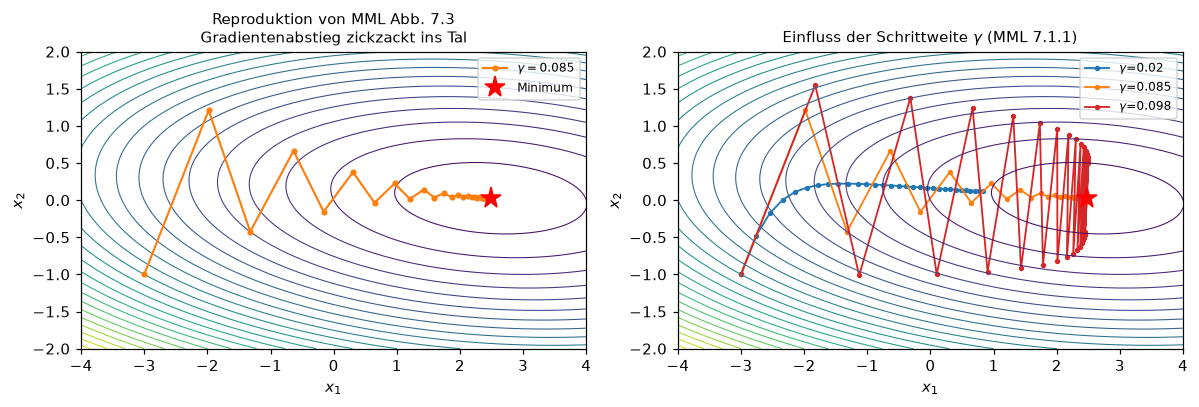

Singulaerwerte von A: [20.05538558959961, 1.9446147680282593]
Konditionszahl  kappa = sigma_max / sigma_min = 10.31

MML S. 230: genau dieses kappa erklaert das Zickzack — die Funktion ist in einer
Richtung ~10x staerker gekruemmt als in der anderen ('langes, schmales Tal').
Zu grosses gamma laeuft entlang der steilen Achse ueber das Ziel hinaus.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# links: Reproduktion von MML Abbildung 7.3
ax = axes[0]
contour_2d(ax, f_mml, xlim=(-4, 4), ylim=(-2, 2), levels=30)
ax.plot(path_book[:, 0], path_book[:, 1], "o-", color="tab:orange", ms=3, lw=1.4, label=r"$\gamma=0.085$")
ax.plot(*x_star, "r*", ms=14, label="Minimum")
ax.set_title("Reproduktion von MML Abb. 7.3\nGradientenabstieg zickzackt ins Tal", fontsize=10)
ax.legend(fontsize=8)

# rechts: warum? -> Kondition der Hesse-Matrix
ax = axes[1]
for gamma, c in [(0.02, "tab:blue"), (0.085, "tab:orange"), (0.098, "tab:red")]:
    p = gd_path(x0, gamma=gamma, steps=30)
    ax.plot(p[:, 0], p[:, 1], "o-", ms=2.5, lw=1.2, color=c, label=f"$\\gamma$={gamma}")
contour_2d(ax, f_mml, xlim=(-4, 4), ylim=(-2, 2), levels=30)
ax.plot(*x_star, "r*", ms=14)
ax.set_title("Einfluss der Schrittweite $\\gamma$ (MML 7.1.1)", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

sv = torch.linalg.svdvals(A_mml)
print(f"Singulaerwerte von A: {sv.tolist()}")
print(f"Konditionszahl  kappa = sigma_max / sigma_min = {(sv[0] / sv[1]).item():.2f}")
print("\nMML S. 230: genau dieses kappa erklaert das Zickzack — die Funktion ist in einer")
print("Richtung ~10x staerker gekruemmt als in der anderen ('langes, schmales Tal').")
print("Zu grosses gamma laeuft entlang der steilen Achse ueber das Ziel hinaus.")

### Momentum und Adam — dasselbe Bild, andere Wege

MML Kap. 7.1.2 (Gl. 7.11/7.12) fügt dem Update ein *Gedächtnis* hinzu:

$$\boldsymbol{x}_{i+1} = \boldsymbol{x}_i - \gamma_i \nabla f(\boldsymbol{x}_i) + \alpha \Delta \boldsymbol{x}_i, \qquad \Delta\boldsymbol{x}_i = \boldsymbol{x}_i - \boldsymbol{x}_{i-1}$$

Anschaulich: eine schwere Kugel, die sich ungern umentscheidet. Oszillationen quer zum Tal löschen sich teilweise aus, die konsistente Richtung entlang des Tals summiert sich auf.

Adam (das wir in Notebook 01 benutzt haben, ohne es zu erklären) kombiniert Momentum mit einer **pro Parameter** adaptiven Schrittweite — genau die Idee aus MML 7.1.1 ("adaptive gradient methods rescale the step-size at each iteration"). Deshalb kommt Adam mit schlecht konditionierten Problemen wie diesem besser klar, ohne dass man $\gamma$ mühsam von Hand tunt.

Jetzt lassen wir alle drei auf demselben Problem laufen — einmal von Hand (GD, Momentum), einmal über `torch.optim` (Adam), damit du siehst, dass `torch.optim` genau dasselbe tut.

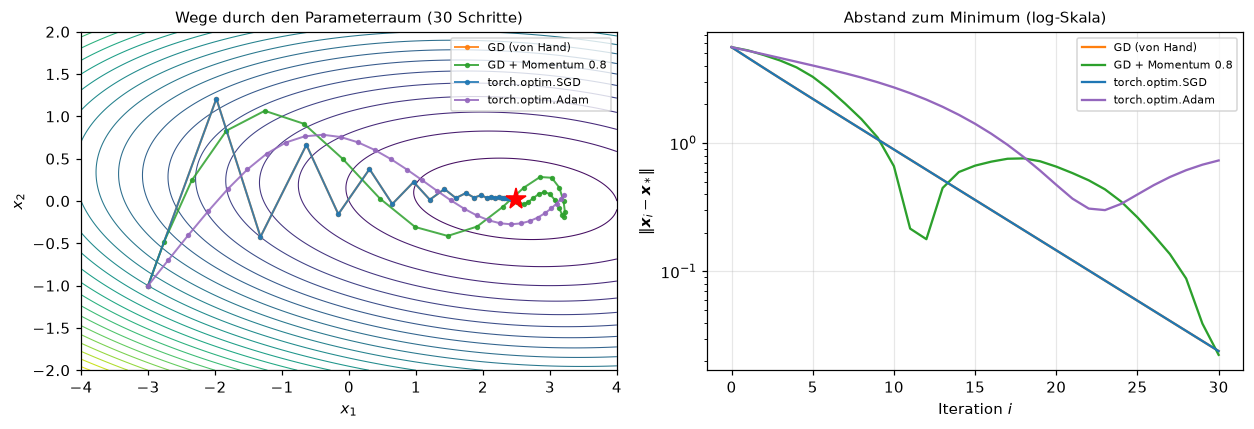

torch.optim.SGD und der handgeschriebene GD liefern denselben Pfad —
ein Optimierer ist genau die Update-Regel aus MML (7.6), nur verwaltet.
max. Abweichung: 1.19e-07


In [11]:
def optim_path(opt_name, x0, steps=30, **kw):
    '''Pfad eines echten torch.optim-Optimierers auf demselben f.'''
    x = x0.clone().requires_grad_(True)
    opt = {"sgd": torch.optim.SGD, "adam": torch.optim.Adam}[opt_name]([x], **kw)
    path = [x.detach().clone()]
    for _ in range(steps):
        opt.zero_grad()
        loss = f_mml(x.unsqueeze(0)).squeeze()
        loss.backward()
        opt.step()
        path.append(x.detach().clone())
    return torch.stack(path)

paths = {
    "GD (von Hand)":            (gd_path(x0, gamma=0.085, steps=30), "tab:orange"),
    "GD + Momentum 0.8":        (gd_path(x0, gamma=0.02, steps=30, momentum=0.8), "tab:green"),
    "torch.optim.SGD":          (optim_path("sgd", x0, lr=0.085), "tab:blue"),
    "torch.optim.Adam":         (optim_path("adam", x0, lr=0.3), "tab:purple"),
}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))

ax = axes[0]
contour_2d(ax, f_mml, xlim=(-4, 4), ylim=(-2, 2), levels=30)
for name, (p, c) in paths.items():
    ax.plot(p[:, 0], p[:, 1], "o-", ms=2.5, lw=1.3, color=c, label=name, alpha=0.85)
ax.plot(*x_star, "r*", ms=14)
ax.set_title("Wege durch den Parameterraum (30 Schritte)", fontsize=10)
ax.legend(fontsize=7.5)

ax = axes[1]
for name, (p, c) in paths.items():
    dist = torch.linalg.norm(p - x_star, dim=1)
    ax.semilogy(dist, color=c, lw=1.5, label=name)
ax.set_xlabel("Iteration $i$")
ax.set_ylabel(r"$\|\boldsymbol{x}_i - \boldsymbol{x}_*\|$")
ax.set_title("Abstand zum Minimum (log-Skala)", fontsize=10)
ax.grid(alpha=0.3)
ax.legend(fontsize=7.5)
plt.tight_layout()
plt.show()

print("torch.optim.SGD und der handgeschriebene GD liefern denselben Pfad —")
print("ein Optimierer ist genau die Update-Regel aus MML (7.6), nur verwaltet.")
print(f"max. Abweichung: {(paths['GD (von Hand)'][0] - paths['torch.optim.SGD'][0]).abs().max():.2e}")

---
## 6. Full-Batch vs. Mini-Batch vs. SGD

Bisher war der Gradient exakt. Mit dem DataLoader ist er ein **Schätzer** aus $B$ Datenpunkten. MML S. 232 sagt, was das kostet und bringt:

> "Large mini-batch sizes will provide accurate estimates of the gradient, reducing the variance in the parameter update. [...] In contrast, small mini-batches are quick to estimate. If we keep the mini-batch size small, the noise in our gradient estimate will allow us to get out of some bad local optima."

Sichtbar gemacht an einer linearen Regression (MML Kap. 9): dasselbe Problem, drei Batchgrößen. Links die Loss-Kurven, rechts die tatsächlichen Wege im Parameterraum $\boldsymbol{\theta} = (w, b)$.

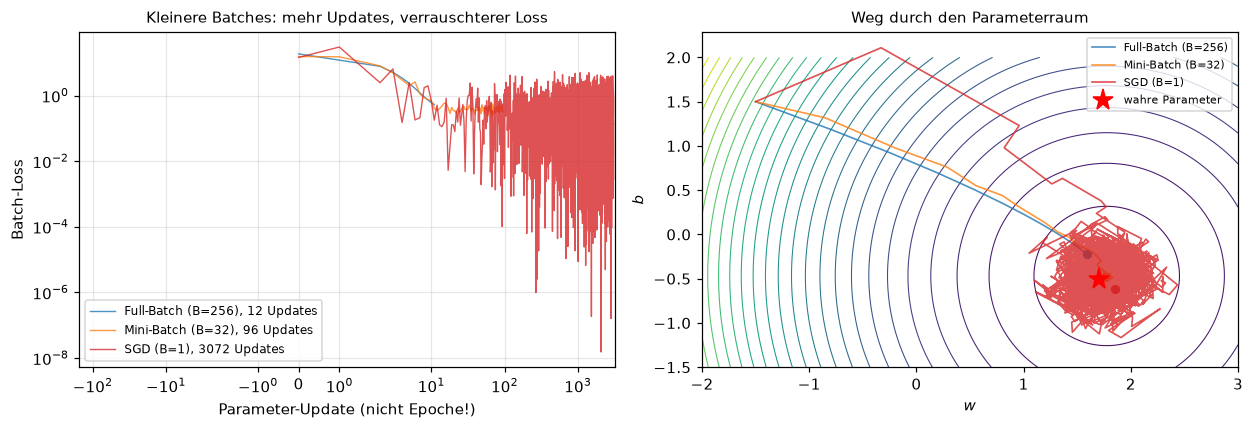

Full-Batch (B=256)          12 Updates   Endpunkt (w,b) = (+1.596, -0.226)
Mini-Batch (B=32)           96 Updates   Endpunkt (w,b) = (+1.755, -0.478)
SGD (B=1)                 3072 Updates   Endpunkt (w,b) = (+1.848, -0.611)
wahre Werte                               (w,b) = (+1.700, -0.500)

B=1 zappelt sichtbar um das Minimum (hohe Varianz), kommt aber mit denselben
12 Epochen am weitesten — es macht eben 256x so viele Updates.


In [12]:
# lineare Regression y = w*x + b, damit der Parameterraum 2D und zeichenbar bleibt
torch.manual_seed(1)
N_reg = 256
x_reg = torch.linspace(-2, 2, N_reg).unsqueeze(1)
w_true, b_true = 1.7, -0.5
y_reg = w_true * x_reg + b_true + 0.6 * torch.randn(N_reg, 1)

def loss_surface(theta):            # theta: (M,2) -> mittlerer quadratischer Fehler
    w, b = theta[:, 0:1], theta[:, 1:2]
    pred = w * x_reg.T + b          # (M, N)
    return ((pred - y_reg.T) ** 2).mean(dim=1)

def train_path(batch_size, epochs=12, lr=0.08, seed=0):
    torch.manual_seed(seed)
    theta = torch.tensor([-1.5, 1.5], requires_grad=True)
    opt = torch.optim.SGD([theta], lr=lr)
    dl = DataLoader(TensorDataset(x_reg, y_reg), batch_size=batch_size, shuffle=True)
    path, losses = [theta.detach().clone()], []
    for _ in range(epochs):
        for xb, yb in dl:
            opt.zero_grad()
            loss = ((theta[0] * xb + theta[1] - yb) ** 2).mean()
            loss.backward()
            opt.step()
            path.append(theta.detach().clone())
            losses.append(loss.item())
    return torch.stack(path), losses

runs = {
    f"Full-Batch (B={N_reg})": (train_path(N_reg), "tab:blue"),
    "Mini-Batch (B=32)":       (train_path(32),    "tab:orange"),
    "SGD (B=1)":               (train_path(1),     "tab:red"),
}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))

ax = axes[0]
for name, ((p, ls), c) in runs.items():
    ax.plot(ls, color=c, lw=0.9, alpha=0.8, label=f"{name}, {len(ls)} Updates")
ax.set_yscale("log"); ax.set_xscale("symlog")
ax.set_xlabel("Parameter-Update (nicht Epoche!)")
ax.set_ylabel("Batch-Loss")
ax.set_title("Kleinere Batches: mehr Updates, verrauschterer Loss", fontsize=10)
ax.grid(alpha=0.3); ax.legend(fontsize=8)

ax = axes[1]
contour_2d(ax, loss_surface, xlim=(-2, 3), ylim=(-1.5, 2), levels=30)
for name, ((p, ls), c) in runs.items():
    ax.plot(p[:, 0], p[:, 1], "-", lw=1.1, color=c, alpha=0.8, label=name)
    ax.plot(p[-1, 0], p[-1, 1], "o", color=c, ms=5)
ax.plot(w_true, b_true, "r*", ms=14, label="wahre Parameter")
ax.set_xlabel("$w$"); ax.set_ylabel("$b$")
ax.set_title("Weg durch den Parameterraum", fontsize=10)
ax.legend(fontsize=7.5)
plt.tight_layout()
plt.show()

for name, ((p, ls), c) in runs.items():
    print(f"{name:24s} {len(ls):5d} Updates   Endpunkt (w,b) = "
          f"({p[-1,0]:+.3f}, {p[-1,1]:+.3f})")
print(f"{'wahre Werte':24s} {'':5s}            (w,b) = ({w_true:+.3f}, {b_true:+.3f})")
print("\nB=1 zappelt sichtbar um das Minimum (hohe Varianz), kommt aber mit denselben")
print("12 Epochen am weitesten — es macht eben 256x so viele Updates.")

---
## 7. `nn.Module` von innen: Parameter, `state_dict`, `train()`/`eval()`

`nn.Module` ist im Kern **Buchführung über $\boldsymbol{\theta}$**: Es sammelt alle Tensoren, die trainiert werden sollen, damit `optimizer` und `backward()` sie finden. Drei Sorten Zustand sind zu unterscheiden:

| Sorte | Beispiel | trainiert? | in `state_dict`? |
|---|---|---|---|
| **Parameter** (`nn.Parameter`) | `weight`, `bias` | ja (`requires_grad=True`) | ja |
| **Buffer** (`register_buffer`) | Mittelwert für Normierung, Kalibrierdaten | nein | ja |
| normales Attribut | `self.hidden_dim = 16` | nein | nein |

Der Unterschied wird für dein Projekt wichtig: Ein Sensor-Kalibrierfaktor gehört als **Buffer** ins Modell — er wandert dann automatisch mit `.to(device)` mit und landet in der gespeicherten Datei, wird aber nicht trainiert.

In [13]:
class PeakNet(nn.Module):
    def __init__(self, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, 1))
        # Buffer: gehoert zum Modellzustand, wird aber NICHT trainiert
        self.register_buffer("x_scale", torch.tensor(3.0))
        self.hidden_dim = hidden_dim              # normales Attribut, kein Zustand

    def forward(self, x):
        return self.net(x / self.x_scale)

model = PeakNet(hidden_dim=16)

print("--- named_parameters(): das ist theta ---")
total = 0
for name, p in model.named_parameters():
    print(f"  {name:14s} {str(tuple(p.shape)):9s} requires_grad={p.requires_grad}  {p.numel():3d} Zahlen")
    total += p.numel()
print(f"  -> dim(theta) = {total}")

print("\n--- named_buffers(): Zustand ohne Gradient ---")
for name, b in model.named_buffers():
    print(f"  {name:14s} {b.item()}")

print("\n--- state_dict(): genau das wird gespeichert ---")
for k, v in model.state_dict().items():
    print(f"  {k:16s} {tuple(v.shape)}")

--- named_parameters(): das ist theta ---
  net.0.weight   (16, 1)   requires_grad=True   16 Zahlen
  net.0.bias     (16,)     requires_grad=True   16 Zahlen
  net.2.weight   (1, 16)   requires_grad=True   16 Zahlen
  net.2.bias     (1,)      requires_grad=True    1 Zahlen
  -> dim(theta) = 49

--- named_buffers(): Zustand ohne Gradient ---
  x_scale        3.0

--- state_dict(): genau das wird gespeichert ---
  x_scale          ()
  net.0.weight     (16, 1)
  net.0.bias       (16,)
  net.2.weight     (1, 16)
  net.2.bias       (1,)


### Wie Gewichte vor und nach dem Training aussehen

Die Initialisierung ist nicht willkürlich: `nn.Linear` zieht standardmäßig aus $\mathcal{U}(-1/\sqrt{D_\text{in}},\, 1/\sqrt{D_\text{in}})$ — klein genug, dass `tanh` nicht sofort sättigt, groß genug, dass die Neuronen unterschiedlich starten. (Zufall als Startpunkt ist nötig: Bei identischen Gewichten bekämen alle Neuronen denselben Gradienten und blieben für immer identisch.)

Nach dem Training siehst du im Bild, wie sich die Verteilung verbreitert — das Netz hat sich seine 16 `tanh`-Basisfunktionen an die richtigen Stellen geschoben.

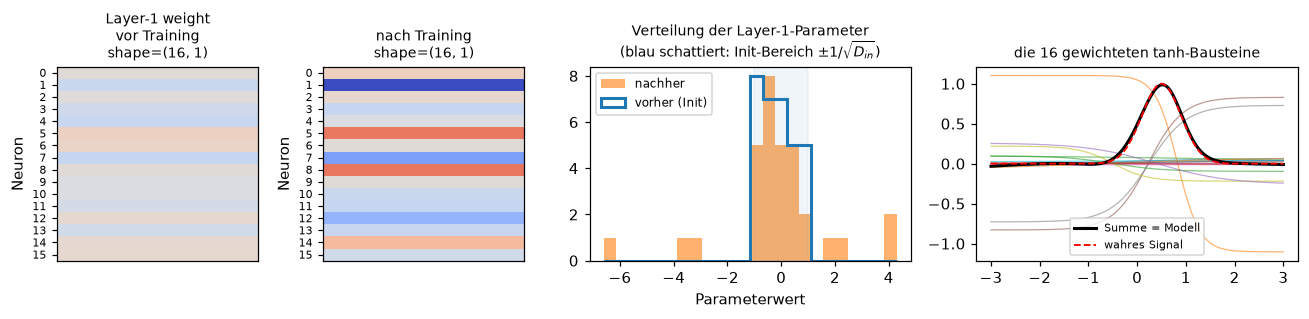

finaler Loss: 0.00178
Rechts siehst du, was 'hidden_dim=16' konkret bedeutet: 16 verschobene, skalierte
tanh-Kurven, deren gewichtete Summe den Peak ergibt (MML Kap. 9: Linearkombination von Basisfunktionen).


In [14]:
# Daten wie in Notebook 01: ein Gauss-Peak mit Rauschen
torch.manual_seed(0)
def true_signal(x):
    return torch.exp(-((x - 0.5) ** 2) / (2 * 0.4 ** 2))

x_nb = torch.linspace(-3, 3, 60).unsqueeze(1)
y_nb = true_signal(x_nb) + 0.05 * torch.randn(60, 1)

model = PeakNet(16)
W0 = model.net[0].weight.detach().clone()
b0 = model.net[0].bias.detach().clone()

opt = torch.optim.Adam(model.parameters(), lr=0.02)
for _ in range(800):
    opt.zero_grad()
    loss = ((model(x_nb) - y_nb) ** 2).mean()
    loss.backward()
    opt.step()

W1 = model.net[0].weight.detach()
b1 = model.net[0].bias.detach()

fig, axes = plt.subplots(1, 4, figsize=(12, 3),
                         gridspec_kw={"width_ratios": [1, 1, 1.6, 1.6]})

vmax = max(W0.abs().max(), W1.abs().max())
show_matrix(axes[0], W0, "Layer-1 weight\nvor Training", cmap="coolwarm", values=False,
            vmin=-vmax, vmax=vmax, aspect="auto")
show_matrix(axes[1], W1, "nach Training", cmap="coolwarm", values=False,
            vmin=-vmax, vmax=vmax, aspect="auto")
for ax in axes[:2]:
    ax.set_ylabel("Neuron")
    ax.set_xticks([])

p0 = torch.cat([W0.flatten(), b0]).numpy()
p1 = torch.cat([W1.flatten(), b1]).numpy()
bins = np.linspace(min(p0.min(), p1.min()), max(p0.max(), p1.max()), 25)
axes[2].hist(p1, bins=bins, alpha=0.6, color="tab:orange", label="nachher")
axes[2].hist(p0, bins=bins, histtype="step", lw=2, color="tab:blue", label="vorher (Init)")
axes[2].axvspan(-1, 1, color="tab:blue", alpha=0.07)
axes[2].set_title("Verteilung der Layer-1-Parameter\n(blau schattiert: Init-Bereich $\\pm 1/\\sqrt{D_{in}}$)", fontsize=9)
axes[2].set_xlabel("Parameterwert")
axes[2].legend(fontsize=8)

# die 16 gelernten Basisfunktionen einzeln
xs = torch.linspace(-3, 3, 200).unsqueeze(1)
with torch.no_grad():
    basis = torch.tanh(model.net[0](xs / model.x_scale))     # (200, 16)
    w_out = model.net[2].weight.squeeze()                    # (16,)
    for k in range(16):
        axes[3].plot(xs, (basis[:, k] * w_out[k]), lw=0.8, alpha=0.6)
    axes[3].plot(xs, model(xs), "k", lw=2, label="Summe = Modell")
axes[3].plot(xs, true_signal(xs), "r--", lw=1.2, label="wahres Signal")
axes[3].set_title("die 16 gewichteten tanh-Bausteine", fontsize=9)
axes[3].legend(fontsize=7)
plt.tight_layout()
plt.show()

print(f"finaler Loss: {loss.item():.5f}")
print("Rechts siehst du, was 'hidden_dim=16' konkret bedeutet: 16 verschobene, skalierte")
print("tanh-Kurven, deren gewichtete Summe den Peak ergibt (MML Kap. 9: Linearkombination von Basisfunktionen).")

### `train()` vs. `eval()` — und Speichern

Manche Schichten verhalten sich beim Training anders als bei der Auswertung. Dropout schaltet im Trainingsmodus zufällig Neuronen ab (Regularisierung), im `eval()`-Modus nicht. Vergisst man `model.eval()`, sind die Vorhersagen zufällig verrauscht — ein Fehler, der in der Auswertung leicht wochenlang unbemerkt bleibt.

Beim Speichern gilt: **`state_dict` speichern, nicht das Modellobjekt.** Das Objekt zu picklen bindet die Datei an deinen Python-Code; das `state_dict` ist nur ein Dictionary aus Tensoren und bleibt lesbar, auch wenn du die Klasse später umbaust.

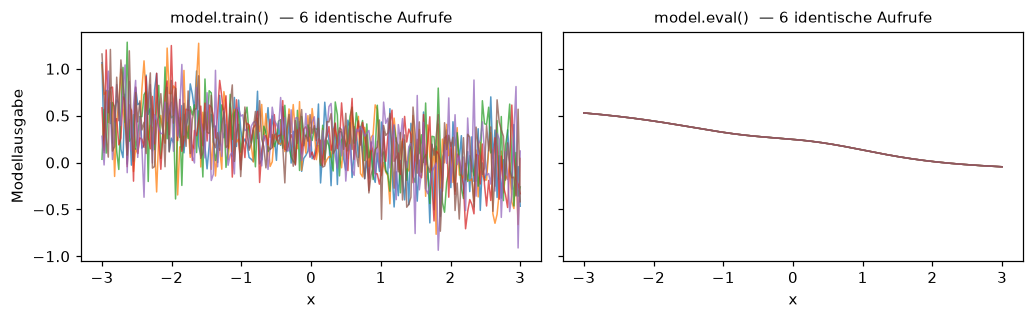

train(): jeder Aufruf anders (Dropout wuerfelt)   eval(): deterministisch

geladenes Modell liefert identische Vorhersagen: True

In echten Skripten:
  torch.save(model.state_dict(), 'model.pt')
  model.load_state_dict(torch.load('model.pt', weights_only=True))
  (weights_only=True ist seit PyTorch 2.6 Default und laedt keine beliebigen Objekte)


In [15]:
drop_model = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Dropout(0.4), nn.Linear(32, 1))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3), sharey=True)
for ax, mode in zip(axes, ["train", "eval"]):
    drop_model.train() if mode == "train" else drop_model.eval()
    with torch.no_grad():
        for _ in range(6):
            ax.plot(xs, drop_model(xs), lw=1, alpha=0.75)
    ax.set_title(f"model.{mode}()  — 6 identische Aufrufe", fontsize=10)
    ax.set_xlabel("x")
axes[0].set_ylabel("Modellausgabe")
plt.tight_layout()
plt.show()

print("train(): jeder Aufruf anders (Dropout wuerfelt)   eval(): deterministisch\n")

# --- Speichern / Laden ---
import io
buf = io.BytesIO()                                  # statt Datei, damit das Notebook nichts liegen laesst
torch.save(model.state_dict(), buf)

restored = PeakNet(16)                              # gleiche Architektur noetig
buf.seek(0)
restored.load_state_dict(torch.load(buf, weights_only=True))
restored.eval()

with torch.no_grad():
    gleich = torch.allclose(model(xs), restored(xs))
print("geladenes Modell liefert identische Vorhersagen:", gleich)
print("\nIn echten Skripten:")
print("  torch.save(model.state_dict(), 'model.pt')")
print("  model.load_state_dict(torch.load('model.pt', weights_only=True))")
print("  (weights_only=True ist seit PyTorch 2.6 Default und laedt keine beliebigen Objekte)")

---
## 8. Devices: CPU vs. MPS — und wann die GPU *nicht* hilft

Auf Apple Silicon heißt die GPU in PyTorch `mps` (Metal Performance Shaders). Die Regel für Devices ist simpel: **Alle Tensoren einer Operation müssen auf demselben Device liegen**, sonst gibt es einen Fehler. Also Modell *und* Daten verschieben.

Wichtig fürs Messen: GPU-Aufrufe sind **asynchron**. Ohne `torch.mps.synchronize()` misst man nur, wie schnell Python die Arbeit *abgeschickt* hat — ein klassischer Grund für absurd gute Benchmark-Zahlen.

In [16]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print("verwendetes Device:", device)

m = PeakNet(16).to(device)
xb = xs.to(device)
print("Parameter liegen auf:", next(m.parameters()).device)
print("Buffer liegt auf    :", m.x_scale.device, " <- Buffer wandern automatisch mit")
with torch.no_grad():
    out = m(xb)
print("Ausgabe liegt auf   :", out.device)
print("\nZurueck zu NumPy/matplotlib geht nur ueber die CPU:")
print("  out.cpu().numpy()  ->", out.cpu().numpy().shape)

verwendetes Device: mps
Parameter liegen auf: mps:0
Buffer liegt auf    : mps:0  <- Buffer wandern automatisch mit
Ausgabe liegt auf   : mps:0

Zurueck zu NumPy/matplotlib geht nur ueber die CPU:
  out.cpu().numpy()  -> (200, 1)


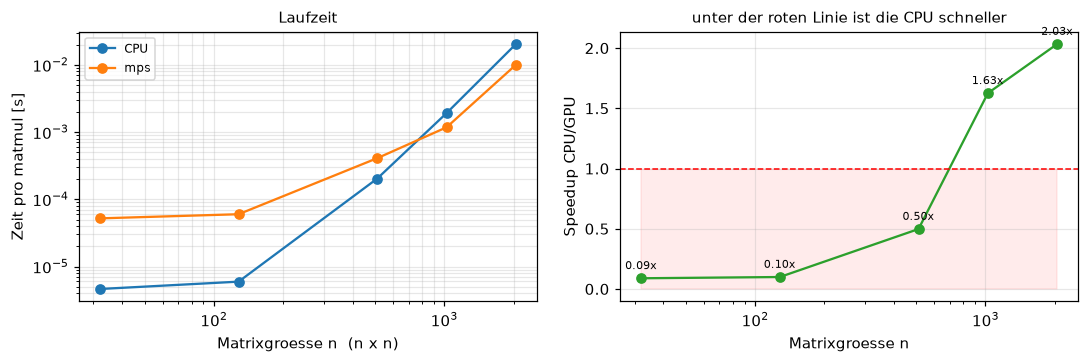

Merke: bei kleinen Tensoren dominiert der Overhead fuers Verschieben/Starten —
die GPU lohnt erst ab einer gewissen Groesse. Unsere Peak-Modelle aus Notebook 01
sind winzig; die laufen auf der CPU schneller als auf der GPU.


In [17]:
import time

def bench(size, device, reps=20):
    '''Zeit fuer eine Matrixmultiplikation (size x size).'''
    a = torch.randn(size, size, device=device)
    b = torch.randn(size, size, device=device)
    for _ in range(3):                       # warmlaufen (erste Aufrufe kompilieren Kernel)
        _ = a @ b
    if device.type == "mps":
        torch.mps.synchronize()
    t0 = time.perf_counter()
    for _ in range(reps):
        _ = a @ b
    if device.type == "mps":                 # OHNE das misst man nur das Abschicken!
        torch.mps.synchronize()
    return (time.perf_counter() - t0) / reps

sizes = [32, 128, 512, 1024, 2048]
t_cpu = [bench(s, torch.device("cpu")) for s in sizes]
t_gpu = [bench(s, device) for s in sizes] if device.type == "mps" else None

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].loglog(sizes, t_cpu, "o-", label="CPU")
if t_gpu:
    axes[0].loglog(sizes, t_gpu, "o-", label=str(device))
axes[0].set_xlabel("Matrixgroesse n  (n x n)"); axes[0].set_ylabel("Zeit pro matmul [s]")
axes[0].set_title("Laufzeit", fontsize=10); axes[0].grid(alpha=0.3, which="both"); axes[0].legend(fontsize=8)

if t_gpu:
    speedup = [c / g for c, g in zip(t_cpu, t_gpu)]
    axes[1].semilogx(sizes, speedup, "o-", color="tab:green")
    axes[1].axhline(1.0, color="red", ls="--", lw=1)
    axes[1].fill_between(sizes, 0, 1, color="red", alpha=0.08)
    axes[1].set_xlabel("Matrixgroesse n"); axes[1].set_ylabel("Speedup CPU/GPU")
    axes[1].set_title("unter der roten Linie ist die CPU schneller", fontsize=10)
    axes[1].grid(alpha=0.3)
    for s, sp in zip(sizes, speedup):
        axes[1].annotate(f"{sp:.2f}x", (s, sp), textcoords="offset points", xytext=(0, 6), fontsize=7, ha="center")
plt.tight_layout()
plt.show()

if t_gpu:
    print("Merke: bei kleinen Tensoren dominiert der Overhead fuers Verschieben/Starten —")
    print("die GPU lohnt erst ab einer gewissen Groesse. Unsere Peak-Modelle aus Notebook 01")
    print("sind winzig; die laufen auf der CPU schneller als auf der GPU.")

---
## 9. Fallstricke, die *still* schiefgehen

Die gefährlichen Fehler sind die ohne Fehlermeldung. Vier Stück, die praktisch jeder einmal macht:

**1. `zero_grad()` vergessen.** PyTorch *addiert* Gradienten auf (das ist Absicht — so kann man Gradienten aus mehreren Teilbatches sammeln). Ohne Zurücksetzen summiert sich der Gradient über alle bisherigen Schritte auf, und die effektive Schrittweite wächst mit jeder Iteration.

**2. `.detach()` vergessen.** Wenn man Zwischenergebnisse in einer Liste sammelt, ohne sie zu lösen, hängt der ganze Berechnungsgraph mit dran → der Speicher läuft langsam voll. `loss.item()` oder `.detach()` löst das.

**3. `float32` als stille Genauigkeitsgrenze.** ML-Standard ist `float32` (schneller, GPU-freundlich). Für numerische Referenzrechnungen — später etwa ODE-Löser oder schlecht konditionierte inverse Probleme — kann das zu ungenau sein. Dann bewusst `float64` wählen.

**4. `model.eval()` vergessen** (siehe Abschnitt 7).

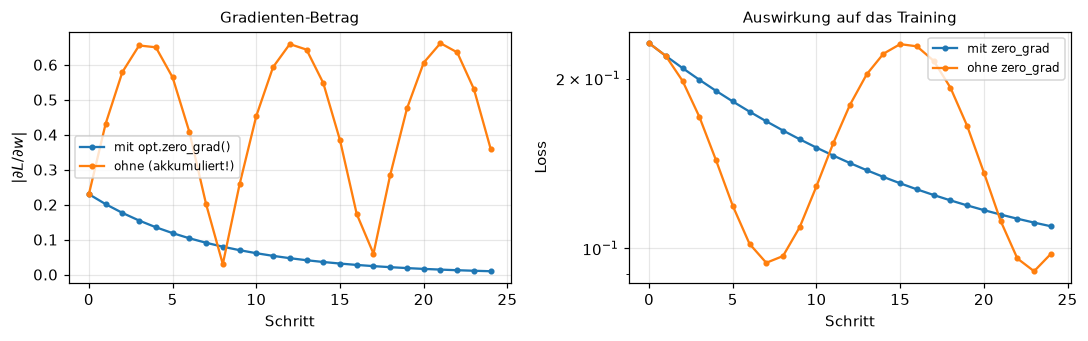

Gradient im letzten Schritt:  mit zero_grad 0.010   ohne 0.359

float32 vs float64:
  kleinste Zahl mit 1 + eps != 1:  float32 1.19e-07   float64 2.22e-16
  (1e-8 + 1) - 1 =  float32 0.00e+00   float64 1.00e-08   <- float32 verschluckt es komplett


In [18]:
def train_grad_trace(zero_grad=True, steps=25, lr=0.02):
    torch.manual_seed(0)
    m = nn.Linear(1, 1)
    opt = torch.optim.SGD(m.parameters(), lr=lr)
    grads, losses = [], []
    for _ in range(steps):
        if zero_grad:
            opt.zero_grad()
        loss = ((m(x_nb) - y_nb) ** 2).mean()
        loss.backward()
        grads.append(m.weight.grad.abs().item())
        losses.append(loss.item())
        opt.step()
    return grads, losses

g_ok, l_ok = train_grad_trace(zero_grad=True)
g_bad, l_bad = train_grad_trace(zero_grad=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].plot(g_ok, "o-", ms=3, label="mit opt.zero_grad()")
axes[0].plot(g_bad, "o-", ms=3, label="ohne (akkumuliert!)")
axes[0].set_xlabel("Schritt"); axes[0].set_ylabel(r"$|\partial L / \partial w|$")
axes[0].set_title("Gradienten-Betrag", fontsize=10); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].semilogy(l_ok, "o-", ms=3, label="mit zero_grad")
axes[1].semilogy(l_bad, "o-", ms=3, label="ohne zero_grad")
axes[1].set_xlabel("Schritt"); axes[1].set_ylabel("Loss")
axes[1].set_title("Auswirkung auf das Training", fontsize=10); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Gradient im letzten Schritt:  mit zero_grad {g_ok[-1]:.3f}   ohne {g_bad[-1]:.3f}")
print("\nfloat32 vs float64:")
a32 = torch.tensor([1.0], dtype=torch.float32)
a64 = torch.tensor([1.0], dtype=torch.float64)
print(f"  kleinste Zahl mit 1 + eps != 1:  float32 {torch.finfo(torch.float32).eps:.2e}"
      f"   float64 {torch.finfo(torch.float64).eps:.2e}")
print(f"  (1e-8 + 1) - 1 =  float32 {((a32 + 1e-8) - 1).item():.2e}"
      f"   float64 {((a64 + 1e-8) - 1).item():.2e}   <- float32 verschluckt es komplett")

---
## 10. Interaktiv: Optimierer-Spielplatz

Dasselbe Problem wie in Abschnitt 5 (MML Beispiel 7.1), jetzt zum Drehen. Vorschläge:

- **`gamma` langsam hochdrehen** (SGD, momentum=0): Ab etwa $\gamma \approx 0.1$ divergiert es — die Grenze hängt am größten Eigenwert von $\boldsymbol{A}$ ($\gamma < 2/\lambda_\max \approx 0.0997$). Rechne das nach: `2 / torch.linalg.eigvalsh(A_mml).max()`.
- **momentum auf 0.9**, dabei `gamma` klein lassen (0.01): Der Pfad wird glatt und schnell — aber er schießt am Ende über und schwingt zurück.
- **Adam** mit derselben `gamma` wie SGD: fast unbeeindruckt von der schlechten Kondition.
- **Startpunkt verschieben**: Bei einer quadratischen (= konvexen) Funktion landet man immer im selben Minimum. Bei der Funktion aus MML Abb. 7.2 wäre das anders — dort entscheidet der Startpunkt, in welchem lokalen Minimum man endet.

In [19]:
from ipywidgets import interact, FloatSlider, Dropdown, IntSlider

def playground(optimizer="SGD", gamma=0.085, momentum=0.0, steps=30, x0_1=-3.0, x0_2=-1.0):
    start = torch.tensor([x0_1, x0_2])
    if optimizer == "SGD":
        p = gd_path(start, gamma=gamma, steps=steps, momentum=momentum)
    else:
        p = optim_path("adam", start, steps=steps, lr=gamma)

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    contour_2d(axes[0], f_mml, xlim=(-5, 5), ylim=(-3, 3), levels=30)
    finite = torch.isfinite(p).all(dim=1)
    axes[0].plot(p[finite, 0], p[finite, 1], "o-", color="tab:orange", ms=3, lw=1.3)
    axes[0].plot(*x_star, "r*", ms=14)
    axes[0].set_xlim(-5, 5); axes[0].set_ylim(-3, 3)
    axes[0].set_title(f"{optimizer}  gamma={gamma:.3f}  momentum={momentum:.2f}", fontsize=10)

    dist = torch.linalg.norm(p - x_star, dim=1)
    axes[1].semilogy(dist, "o-", ms=3, color="tab:orange")
    axes[1].set_xlabel("Iteration"); axes[1].set_ylabel(r"$\|x_i - x_*\|$")
    axes[1].grid(alpha=0.3)
    end = dist[-1].item()
    axes[1].set_title("konvergiert" if end < 1e-2 else
                      ("divergiert!" if (not torch.isfinite(dist[-1])) or end > 10 else
                       f"Endabstand {end:.3f}"), fontsize=10)
    plt.tight_layout()
    plt.show()

interact(
    playground,
    optimizer=Dropdown(options=["SGD", "Adam"], value="SGD"),
    gamma=FloatSlider(min=0.005, max=0.15, step=0.005, value=0.085, readout_format=".3f"),
    momentum=FloatSlider(min=0.0, max=0.95, step=0.05, value=0.0),
    steps=IntSlider(min=5, max=100, step=5, value=30),
    x0_1=FloatSlider(min=-4, max=4, step=0.5, value=-3.0),
    x0_2=FloatSlider(min=-2.5, max=2.5, step=0.5, value=-1.0),
);

interactive(children=(Dropdown(description='optimizer', options=('SGD', 'Adam'), value='SGD'), FloatSlider(val…

---
## 11. Zusammenfassung

| Thema | Kernaussage |
|---|---|
| Tensor | flacher Speicher + `shape`/`stride`/`dtype`/`device`; `view`/`.T` kopieren **nicht** |
| Broadcasting | Achsen der Länge 1 werden gestreckt — Quelle stiller Bugs: `(N,)` vs. `(N,1)` |
| Design-Matrix | $\boldsymbol{X}\in\mathbb{R}^{N\times D}$: Zeile = Datenpunkt, Spalte = Feature |
| DataLoader | zieht Mini-Batches = erwartungstreuer Schätzer von $\nabla L$ (MML 7.1.3) |
| Optimierer | `torch.optim` ist die Update-Regel (7.6) plus Buchführung; Momentum (7.11/7.12) glättet, Adam skaliert pro Parameter |
| Kondition | $\kappa = \sigma_\max/\sigma_\min$ erklärt Zickzack und die $\gamma$-Grenze |
| Batchgröße | klein = viele, verrauschte Updates; groß = wenige, präzise |
| `nn.Module` | Parameter (trainiert) vs. Buffer (Zustand) vs. Attribut (nichts davon) |
| Device | alles auf dasselbe Device; GPU lohnt erst ab Größe; `synchronize()` beim Messen |
| Fallstricke | `zero_grad()`, `.detach()`, `eval()`, `float32`-Genauigkeit |

### Was als Nächstes kommt

`03_autodiff` — die Mechanik hinter `loss.backward()`: Berechnungsgraph, Kettenregel, Vorwärts- vs. Rückwärtsmodus. Das ist MML **Kap. 5.6** ("Backpropagation and Automatic Differentiation", S. 159) und die direkte Voraussetzung für PINNs, wo Ableitungen nicht mehr nur nach $\boldsymbol{\theta}$, sondern **nach der Eingabe** $x$ gebraucht werden.

---

## Videos & Standardliteratur

### Zuerst schauen (Intuition)

- **3Blue1Brown — Neural Networks** ([Playlist](https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi)): der Klassiker für visuelle Intuition. Teil 1 "But what is a neural network?", Teil 2 Gradient Descent, Teil 3/4 Backpropagation. ~15 min pro Folge, unschlagbar für das mentale Bild.
- **3Blue1Brown — Essence of Linear Algebra** ([Playlist](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab)): Matrizen als lineare Abbildungen. Deckt visuell ab, was MML Kap. 2–4 formal macht — besonders die Folgen zu Eigenwerten und Determinanten helfen beim Konditionszahl-Thema aus Abschnitt 5.
- **Andrej Karpathy — Neural Networks: Zero to Hero** ([Kurs](https://karpathy.ai/zero-to-hero.html)): Die erste Folge ([micrograd](https://www.youtube.com/watch?v=VMj-3S1tku0), 2.5 h) baut Autograd komplett von Hand. Wenn du eine Sache vor Notebook 03 schaust, dann diese.

### Standardliteratur

- **Deisenroth, Faisal, Ong — *Mathematics for Machine Learning*** ([mml-book.com](https://mml-book.com/)) — dein Buch. Für dieses Notebook: Kap. 7.1 (Optimierung), Kap. 8.1–8.2 (Daten, Modelle, ERM). Kostenlos als PDF, mit Übungen.
- **Goodfellow, Bengio, Courville — *Deep Learning*** ([deeplearningbook.org](https://www.deeplearningbook.org/)): das Standardwerk. Kap. 8 (Optimierung) ergänzt MML 7.1 um die praktische Seite (Adam, Initialisierung, Batch-Effekte).
- **Zhang et al. — *Dive into Deep Learning*** ([d2l.ai](https://d2l.ai/)): interaktives Lehrbuch, jedes Kapitel mit lauffähigem PyTorch-Code. Gute Ergänzung, weil Mathe und Implementierung direkt nebeneinander stehen.
- **Nielsen — *Neural Networks and Deep Learning*** ([Online-Buch](http://neuralnetworksanddeeplearning.com/)): sehr gut geschriebene Einführung mit interaktiven Grafiken, v. a. Kap. 2 zu Backpropagation.

### Vertiefung zu diesem Notebook

- **Goh — *Why Momentum Really Works*** ([distill.pub](https://distill.pub/2017/momentum/)): interaktiver Artikel, genau zu Abschnitt 5 — und in MML S. 230 als Randnotiz empfohlen. Zeigt den Zusammenhang zwischen Momentum, Kondition und Konvergenzrate zum Anfassen.
- **Ruder — *An overview of gradient descent optimization algorithms*** ([ruder.io](https://www.ruder.io/optimizing-gradient-descent/)): systematischer Vergleich SGD → Momentum → Adagrad → Adam.
- **PyTorch-Dokumentation**: [Tensor-Grundlagen](https://docs.pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html), [Datasets & DataLoader](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html), [`nn.Module`-Notes](https://docs.pytorch.org/docs/stable/notes/modules.html), [MPS-Backend](https://docs.pytorch.org/docs/stable/notes/mps.html).

### Mit Blick auf das Projekt

- **Brunton & Kutz — *Data-Driven Science and Engineering*** ([databookuw.com](https://www.databookuw.com/), Videos auf [YouTube](https://www.youtube.com/c/Eigensteve)): aus der Ingenieurs-/Physikperspektive geschrieben — SVD, Regression, inverse Probleme, Systemidentifikation, später auch PINNs. Das ist die Brücke von hier zu `05_inverse_problems`.